# 07 Evaluate Predictions

Notebook nay danh gia artifact tu step 06 theo cach de theo doi hon:

- tong quan metric va bootstrap interval
- confusion matrix va cac plot overview cho routing / backend / decision source
- phan bo confidence, calibrated probability va runtime
- project-level breakdown, error mix, LLM latency / token usage
- bang false positive / false negative de soat loi


In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / 'evaluate_predictions.py').exists():
    baseline_dir = NOTEBOOK_DIR
else:
    baseline_dir = Path('GRACE-improve/baseline').resolve()

if str(baseline_dir) not in sys.path:
    sys.path.insert(0, str(baseline_dir))


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from evaluate_predictions import (
    EXPECTED_SCHEMA_VERSION,
    default_prediction_paths,
    evaluate_prediction_artifacts,
    write_evaluation_summary,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 160)
pd.set_option('display.max_columns', 24)

PALETTE = {
    'skip': '#2a9d8f',
    'uncertain': '#e9c46a',
    'high': '#e76f51',
    'prefilter': '#264653',
    'llm': '#f4a261',
    'Correct': '#2a9d8f',
    'False Positive': '#e76f51',
    'False Negative': '#577590',
    'Vulnerable': '#d62828',
    'Non-vulnerable': '#277da1',
    'none': '#adb5bd',
}

RISK_BAND_ORDER = ['skip', 'uncertain', 'high']
DECISION_SOURCE_ORDER = ['prefilter', 'llm']
ERROR_ORDER = ['Correct', 'False Positive', 'False Negative']


In [3]:
DATASET_NAME = 'devign'
BASELINE_COMPARE_PATH = None  # Vi du: Path('GRACE-improve/baseline/artifacts/predictions/devign/other_predictions.jsonl')
BOOTSTRAP_ITERATIONS = 1000
WRITE_SUMMARY_JSON = True
TOP_K_ERRORS = 20
TOP_K_PROJECTS = 10

PREDICTIONS_PATH, RUN_STATE_PATH = default_prediction_paths(DATASET_NAME)


In [4]:
print(f'dataset={DATASET_NAME}')
print(f'predictions={PREDICTIONS_PATH}')
print(f'run_state={RUN_STATE_PATH}')
print(f'baseline_compare={BASELINE_COMPARE_PATH or "None"}')


dataset=devign
predictions=C:\Users\Admin\Documents\1. UET\lab\VulGuardVN\GRACE-improve\baseline\artifacts\predictions\devign\grace_prefilter_predictions.jsonl
run_state=C:\Users\Admin\Documents\1. UET\lab\VulGuardVN\GRACE-improve\baseline\artifacts\predictions\devign\grace_prefilter_run_state.json
baseline_compare=None


In [5]:
rows, run_state, metrics = evaluate_prediction_artifacts(
    PREDICTIONS_PATH,
    RUN_STATE_PATH,
    dataset_name=DATASET_NAME,
    baseline_compare_path=BASELINE_COMPARE_PATH,
    expected_schema_version=EXPECTED_SCHEMA_VERSION,
    bootstrap_iterations=BOOTSTRAP_ITERATIONS,
)

df = pd.DataFrame(rows)
df['ground_truth'] = df['ground_truth'].astype(int)
df['prediction'] = df['prediction'].astype(int)
df['is_correct'] = df['ground_truth'] == df['prediction']
df['error_type'] = 'Correct'
df.loc[(df['ground_truth'] == 0) & (df['prediction'] == 1), 'error_type'] = 'False Positive'
df.loc[(df['ground_truth'] == 1) & (df['prediction'] == 0), 'error_type'] = 'False Negative'

numeric_columns = [
    'calibrated_probability',
    'prefilter_probability',
    'llm_confidence',
    'record_runtime_ms',
    'retrieval_latency_ms',
    'graph_latency_ms',
    'llm_latency_ms',
    'llm_prompt_tokens',
    'llm_generated_tokens',
]
for column in numeric_columns:
    if column not in df.columns:
        df[column] = np.nan
    df[column] = pd.to_numeric(df[column], errors='coerce')

default_columns = {
    'llm_called': False,
    'api_request_made': False,
    'project': 'unknown',
    'risk_band': 'unknown',
    'decision_source': 'unknown',
    'graph_backend_used': 'none',
    'reason': '',
}
for column, default_value in default_columns.items():
    if column not in df.columns:
        df[column] = default_value
    else:
        df[column] = df[column].fillna(default_value)

df['llm_called'] = df['llm_called'].astype(bool)
df['api_request_made'] = df['api_request_made'].astype(bool)
df['actual_label_name'] = df['ground_truth'].map({0: 'Non-vulnerable', 1: 'Vulnerable'})
df['predicted_label_name'] = df['prediction'].map({0: 'Non-vulnerable', 1: 'Vulnerable'})
df['confidence_score'] = df['llm_confidence'].fillna(df['calibrated_probability'])
df['record_runtime_ms'] = df['record_runtime_ms'].fillna(0.0)
df['runtime_seconds'] = df['record_runtime_ms'] / 1000.0

llm_df = df[df['llm_called']].copy()

project_summary_df = (
    df.groupby('project')
    .agg(
        samples=('record_id', 'size'),
        accuracy=('is_correct', 'mean'),
        llm_call_ratio=('llm_called', 'mean'),
        avg_runtime_ms=('record_runtime_ms', 'mean'),
        false_positives=('error_type', lambda values: int((values == 'False Positive').sum())),
        false_negatives=('error_type', lambda values: int((values == 'False Negative').sum())),
    )
    .sort_values(['samples', 'accuracy'], ascending=[False, False])
)
project_summary_df['error_count'] = project_summary_df['false_positives'] + project_summary_df['false_negatives']

metrics


{'accuracy': 0.5737824972537532,
 'precision': 0.5180616740088105,
 'recall': 0.9438202247191011,
 'f1': 0.6689419795221843,
 'tp': 1176,
 'tn': 391,
 'fp': 1094,
 'fn': 70,
 'roc_auc': 0.7067223870594657,
 'pr_auc': 0.6586710279489674,
 'dataset': 'devign',
 'model_name': 'Virtue-AI-HUB/VulnLLM-R-7B',
 'experiment_mode': 'local_uncertain_only',
 'schema_version': 4,
 'samples': 2731,
 'llm_calls': 552,
 'api_requests_made': 552,
 'llm_cache_hits': 0,
 'llm_call_ratio': 0.2021237641889418,
 'routing': {'uncertain': 552, 'high': 2008, 'skip': 171},
 'decision_sources': {'llm': 552, 'prefilter': 2179},
 'retrieval_backend': 'codet5',
 'graph_backend_requested': 'auto',
 'graph_backend_counts': {'heuristic': 1909},
 'timing_ms': {'graph_total': 20601.97499999998,
  'graph_mean': 10.79202462022,
  'retrieval_total': 428334.3610000009,
  'retrieval_mean': 224.3763022524887,
  'llm_total': 47951277.62399989,
  'llm_mean': 25118.532018857986,
  'record_total': 48400799.96800001,
  'record_mea

In [6]:
def format_metric(value):
    if value is None or pd.isna(value):
        return '-'
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    return f'{float(value):.4f}'


def shorten_text(value, limit=160):
    if not isinstance(value, str):
        return value
    if len(value) <= limit:
        return value
    return value[: limit - 3].rstrip() + '...'


def show_section(title):
    display(Markdown(f'## {title}'))


def annotate_bars(ax, decimals=0):
    for patch in ax.patches:
        width = patch.get_width()
        height = patch.get_height()
        if np.isnan(width) or np.isnan(height):
            continue
        if height >= width:
            x = patch.get_x() + patch.get_width() / 2
            y = patch.get_y() + patch.get_height()
            value = height
            ax.annotate(f'{value:.{decimals}f}', (x, y), ha='center', va='bottom', fontsize=9, xytext=(0, 4), textcoords='offset points')
        else:
            x = patch.get_x() + patch.get_width()
            y = patch.get_y() + patch.get_height() / 2
            value = width
            ax.annotate(f'{value:.{decimals}f}', (x, y), ha='left', va='center', fontsize=9, xytext=(4, 0), textcoords='offset points')


def draw_confusion_heatmap(ax, table, title):
    matrix = table.to_numpy(dtype=float)
    image = ax.imshow(matrix, cmap='Blues')
    ax.set_xticks(range(table.shape[1]))
    ax.set_yticks(range(table.shape[0]))
    ax.set_xticklabels(table.columns)
    ax.set_yticklabels(table.index)
    ax.set_title(title)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    threshold = matrix.max() / 2 if matrix.size else 0
    for row_idx in range(table.shape[0]):
        for col_idx in range(table.shape[1]):
            value = int(matrix[row_idx, col_idx])
            color = 'white' if value > threshold else 'black'
            ax.text(col_idx, row_idx, str(value), ha='center', va='center', color=color, fontsize=11)
    ax.figure.colorbar(image, ax=ax, fraction=0.046, pad=0.04)


def draw_boxplot(ax, grouped_series, title, ylabel, log_scale=False):
    valid_groups = []
    labels = []
    for label, values in grouped_series:
        series = pd.Series(values).dropna()
        if series.empty:
            continue
        valid_groups.append(series)
        labels.append(label)
    if not valid_groups:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        ax.set_axis_off()
        return
    boxplot = ax.boxplot(valid_groups, tick_labels=labels, patch_artist=True, showfliers=False)
    for patch, label in zip(boxplot['boxes'], labels):
        patch.set_facecolor(PALETTE.get(label, '#8d99ae'))
        patch.set_alpha(0.75)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    if log_scale:
        ax.set_yscale('log')
    ax.tick_params(axis='x', rotation=20)


def pick_colors(labels):
    return [PALETTE.get(label, '#8d99ae') for label in labels]


In [7]:
summary_df = pd.DataFrame(
    [
        {'metric': 'Accuracy', 'value': metrics.get('accuracy')},
        {'metric': 'Precision', 'value': metrics.get('precision')},
        {'metric': 'Recall', 'value': metrics.get('recall')},
        {'metric': 'F1', 'value': metrics.get('f1')},
        {'metric': 'ROC-AUC', 'value': metrics.get('roc_auc')},
        {'metric': 'PR-AUC', 'value': metrics.get('pr_auc')},
        {'metric': 'LLM call ratio', 'value': metrics.get('llm_call_ratio')},
        {'metric': 'Samples', 'value': metrics.get('samples')},
        {'metric': 'LLM calls', 'value': metrics.get('llm_calls')},
        {'metric': 'API requests', 'value': metrics.get('api_requests_made')},
    ]
)
summary_display_df = summary_df.assign(value=summary_df['value'].apply(format_metric))

bootstrap_df = pd.DataFrame([
    {
        'mean_f1': format_metric(metrics.get('bootstrap_f1', {}).get('mean')),
        'low_95': format_metric(metrics.get('bootstrap_f1', {}).get('low')),
        'high_95': format_metric(metrics.get('bootstrap_f1', {}).get('high')),
    }
])

confusion_df = pd.DataFrame(
    [[metrics.get('tn'), metrics.get('fp')], [metrics.get('fn'), metrics.get('tp')]],
    index=['Actual 0', 'Actual 1'],
    columns=['Pred 0', 'Pred 1'],
)

run_meta_df = pd.DataFrame([
    {'field': 'Dataset', 'value': metrics.get('dataset')},
    {'field': 'Model', 'value': metrics.get('model_name')},
    {'field': 'Experiment mode', 'value': metrics.get('experiment_mode')},
    {'field': 'Retrieval backend', 'value': metrics.get('retrieval_backend')},
    {'field': 'Graph backend requested', 'value': metrics.get('graph_backend_requested')},
    {'field': 'Predictions path', 'value': metrics.get('predictions_path')},
    {'field': 'Run state path', 'value': metrics.get('run_state_path')},
])

timing_ms = metrics.get('timing_ms') or {}
timing_stage_df = pd.DataFrame([
    {'stage': 'graph', 'total_seconds': (timing_ms.get('graph_total') or 0.0) / 1000.0, 'mean_ms': timing_ms.get('graph_mean') or 0.0},
    {'stage': 'retrieval', 'total_seconds': (timing_ms.get('retrieval_total') or 0.0) / 1000.0, 'mean_ms': timing_ms.get('retrieval_mean') or 0.0},
    {'stage': 'llm', 'total_seconds': (timing_ms.get('llm_total') or 0.0) / 1000.0, 'mean_ms': timing_ms.get('llm_mean') or 0.0},
    {'stage': 'record_total', 'total_seconds': (timing_ms.get('record_total') or 0.0) / 1000.0, 'mean_ms': timing_ms.get('record_mean') or 0.0},
])
timing_display_df = timing_stage_df.copy()
timing_display_df['total_seconds'] = timing_display_df['total_seconds'].map(format_metric)
timing_display_df['mean_ms'] = timing_display_df['mean_ms'].map(format_metric)

llm_stats_df = pd.DataFrame()
if not llm_df.empty:
    llm_stats_df = pd.DataFrame([
        {
            'llm_samples': int(len(llm_df)),
            'prompt_tokens_mean': format_metric(llm_df['llm_prompt_tokens'].mean()),
            'generated_tokens_mean': format_metric(llm_df['llm_generated_tokens'].mean()),
            'llm_latency_ms_mean': format_metric(llm_df['llm_latency_ms'].mean()),
            'llm_latency_ms_p95': format_metric(llm_df['llm_latency_ms'].quantile(0.95)),
        }
    ])

show_section('Summary Metrics')
display(summary_display_df)
show_section('Bootstrap F1 Interval')
display(bootstrap_df)
show_section('Confusion Matrix')
display(confusion_df)
show_section('Run Metadata')
display(run_meta_df)
show_section('Timing Summary')
display(timing_display_df)

if not llm_stats_df.empty:
    show_section('LLM Summary')
    display(llm_stats_df)

summary_output_path = None
if WRITE_SUMMARY_JSON:
    summary_output_path = write_evaluation_summary(metrics, dataset_name=DATASET_NAME)
    print(f'Wrote evaluation summary to {summary_output_path}')


## Summary Metrics

,metric,value
0,Accuracy,0.5738
1,Precision,0.5181
2,Recall,0.9438
3,F1,0.6689
4,ROC-AUC,0.7067
5,PR-AUC,0.6587
6,LLM call ratio,0.2021
7,Samples,2731.0000
8,LLM calls,552.0000
9,API requests,552.0000


## Bootstrap F1 Interval

,mean_f1,low_95,high_95
0,0.6691,0.6518,0.6865


## Confusion Matrix

...

## Timing Summary

,stage,total_seconds,mean_ms
0,graph,20.6020,10.7920
1,retrieval,428.3344,224.3763
2,llm,47951.2776,25118.5320
3,record_total,48400.8000,17722.7389


## LLM Summary

,llm_samples,prompt_tokens_mean,generated_tokens_mean,llm_latency_ms_mean,llm_latency_ms_p95
0,552,1939.3696,51.6033,16501.2309,58191.2397


Wrote evaluation summary to C:\Users\Admin\Documents\1. UET\lab\VulGuardVN\GRACE-improve\baseline\artifacts\metrics\devign\evaluation_summary.json


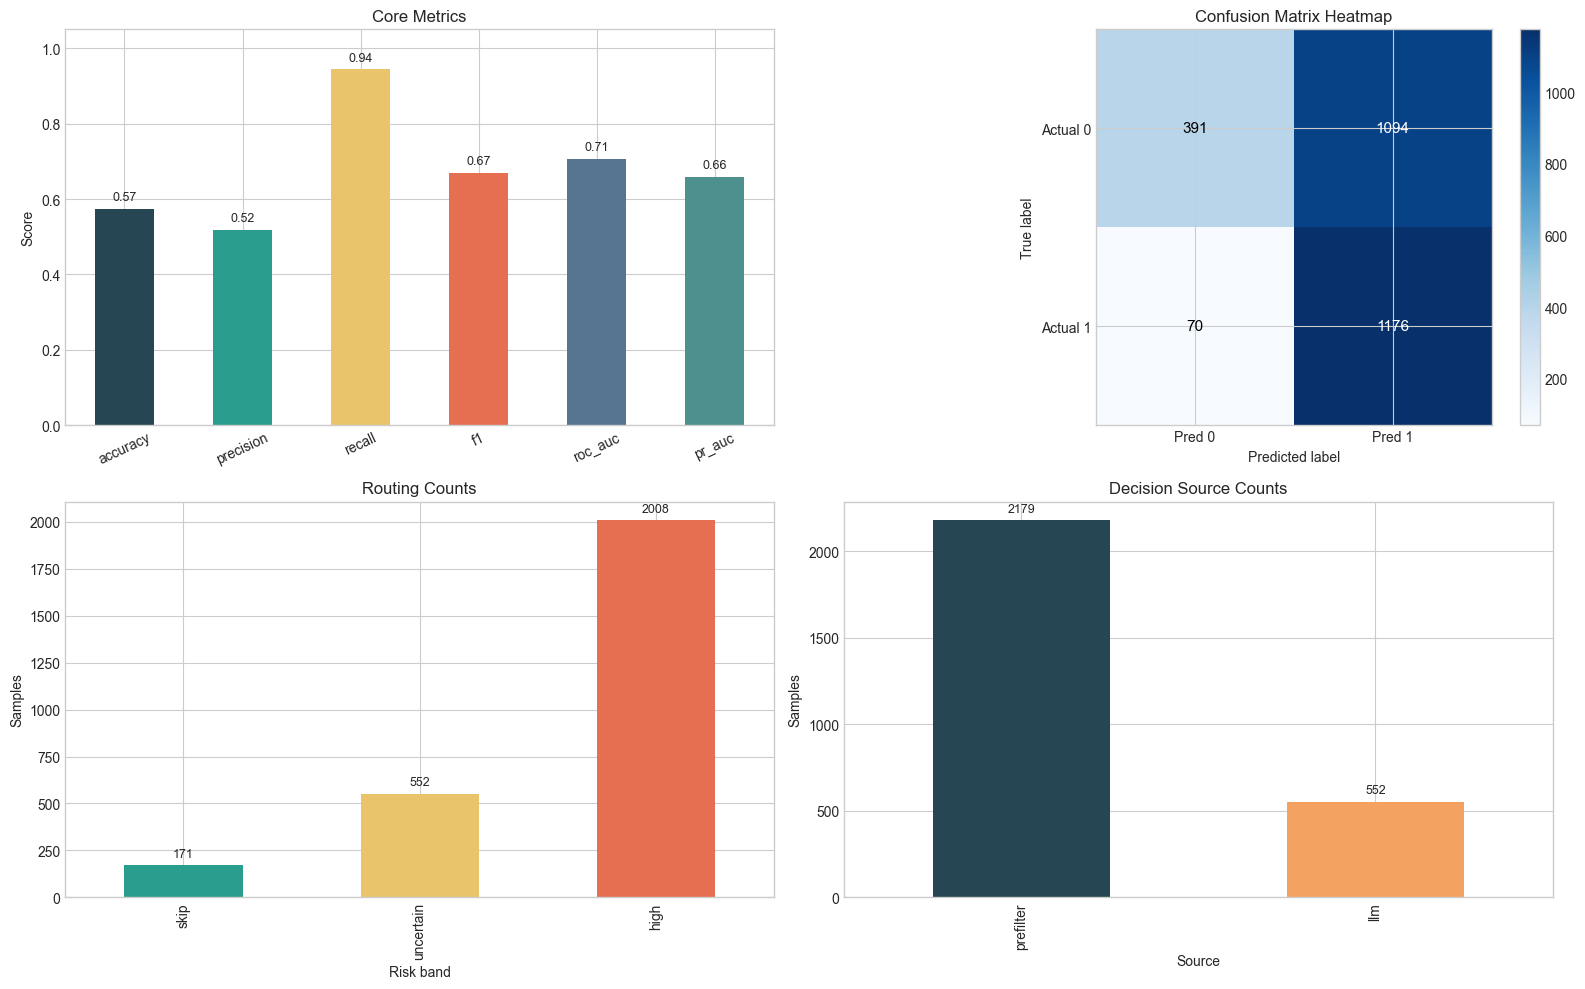

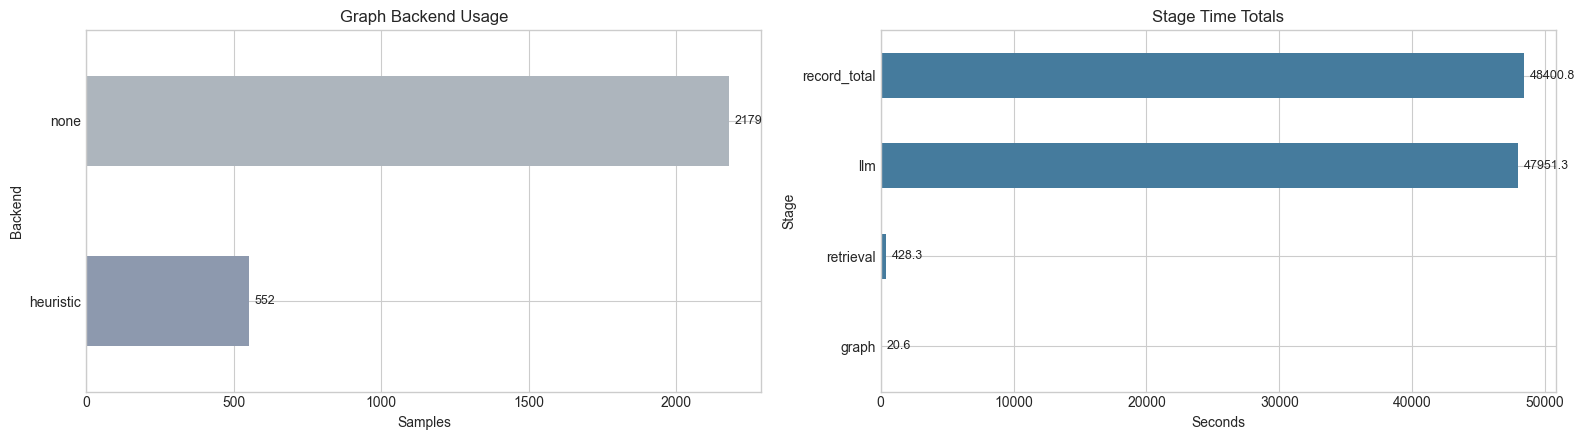

In [8]:
score_series = pd.Series({
    'accuracy': metrics.get('accuracy') or 0.0,
    'precision': metrics.get('precision') or 0.0,
    'recall': metrics.get('recall') or 0.0,
    'f1': metrics.get('f1') or 0.0,
    'roc_auc': metrics.get('roc_auc') or 0.0,
    'pr_auc': metrics.get('pr_auc') or 0.0,
})

routing_counts = pd.Series(metrics.get('routing') or {}).reindex(RISK_BAND_ORDER).fillna(0)
decision_counts = pd.Series(metrics.get('decision_sources') or {}).reindex(DECISION_SOURCE_ORDER).fillna(0)
graph_counts = df['graph_backend_used'].value_counts().sort_values(ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
score_series.plot(kind='bar', ax=axes[0, 0], color=['#264653', '#2a9d8f', '#e9c46a', '#e76f51', '#577590', '#4d908e'])
axes[0, 0].set_ylim(0, 1.05)
axes[0, 0].set_title('Core Metrics')
axes[0, 0].set_ylabel('Score')
axes[0, 0].tick_params(axis='x', rotation=25)
annotate_bars(axes[0, 0], decimals=2)

draw_confusion_heatmap(axes[0, 1], confusion_df, 'Confusion Matrix Heatmap')

routing_counts.plot(kind='bar', ax=axes[1, 0], color=pick_colors(routing_counts.index.tolist()))
axes[1, 0].set_title('Routing Counts')
axes[1, 0].set_xlabel('Risk band')
axes[1, 0].set_ylabel('Samples')
annotate_bars(axes[1, 0], decimals=0)

decision_counts.plot(kind='bar', ax=axes[1, 1], color=pick_colors(decision_counts.index.tolist()))
axes[1, 1].set_title('Decision Source Counts')
axes[1, 1].set_xlabel('Source')
axes[1, 1].set_ylabel('Samples')
annotate_bars(axes[1, 1], decimals=0)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
graph_counts.plot(kind='barh', ax=axes[0], color=pick_colors(graph_counts.index.tolist()))
axes[0].set_title('Graph Backend Usage')
axes[0].set_xlabel('Samples')
axes[0].set_ylabel('Backend')
annotate_bars(axes[0], decimals=0)

timing_stage_df.sort_values('total_seconds').plot(kind='barh', x='stage', y='total_seconds', ax=axes[1], color='#457b9d', legend=False)
axes[1].set_title('Stage Time Totals')
axes[1].set_xlabel('Seconds')
axes[1].set_ylabel('Stage')
annotate_bars(axes[1], decimals=1)

plt.tight_layout()
plt.show()


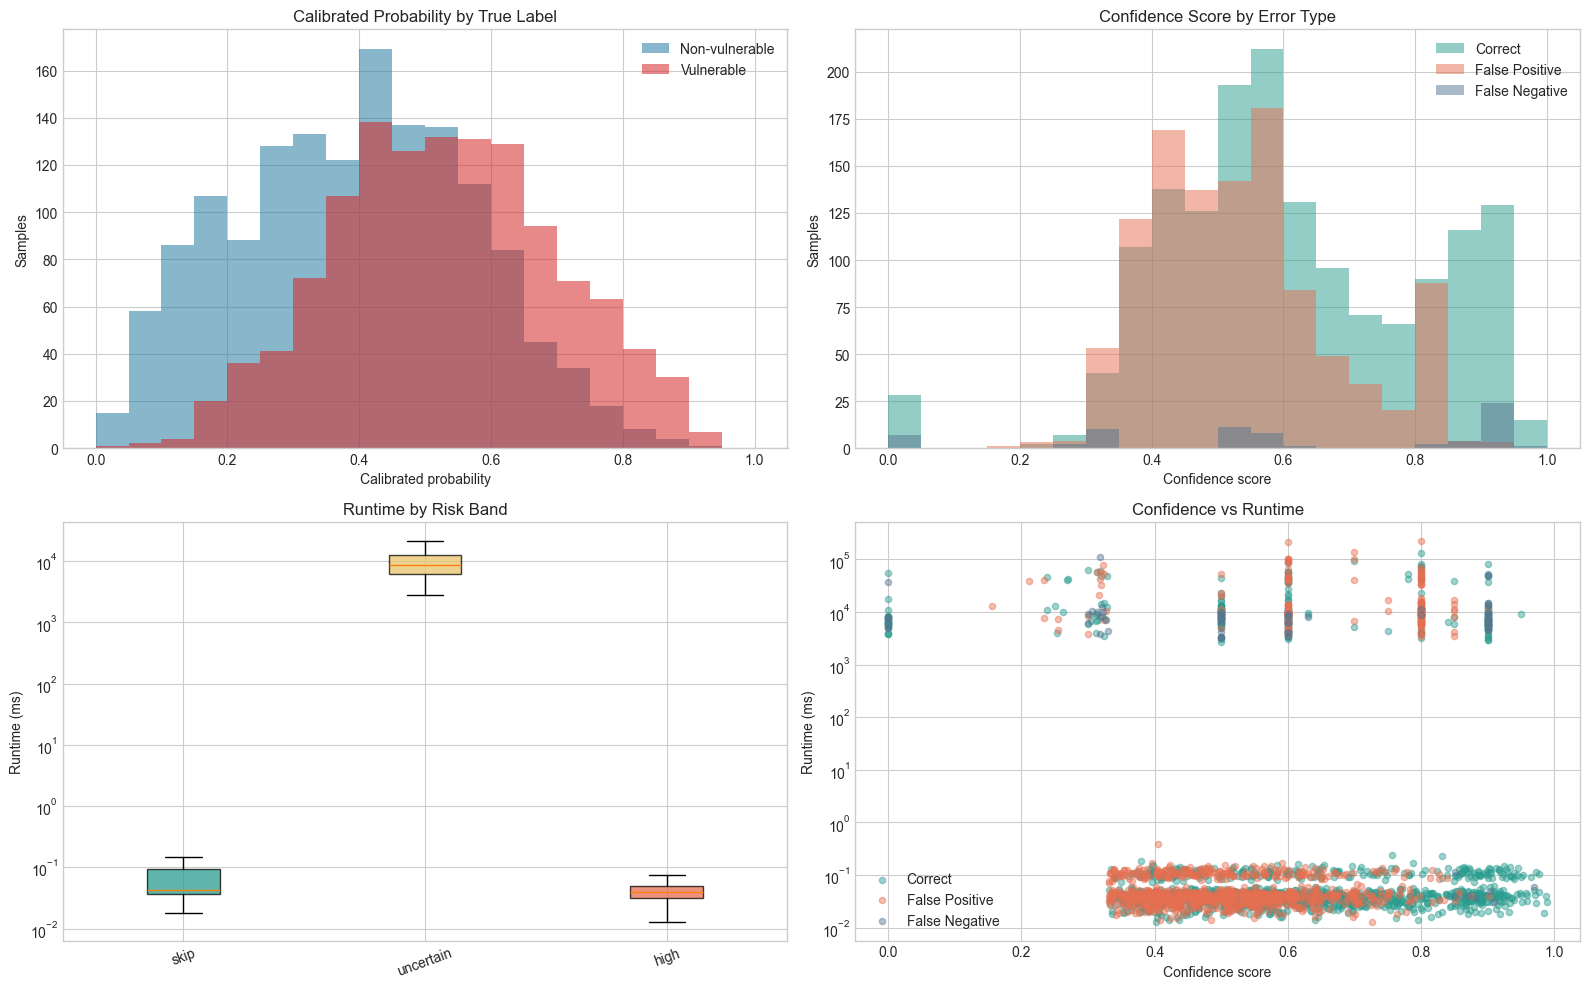

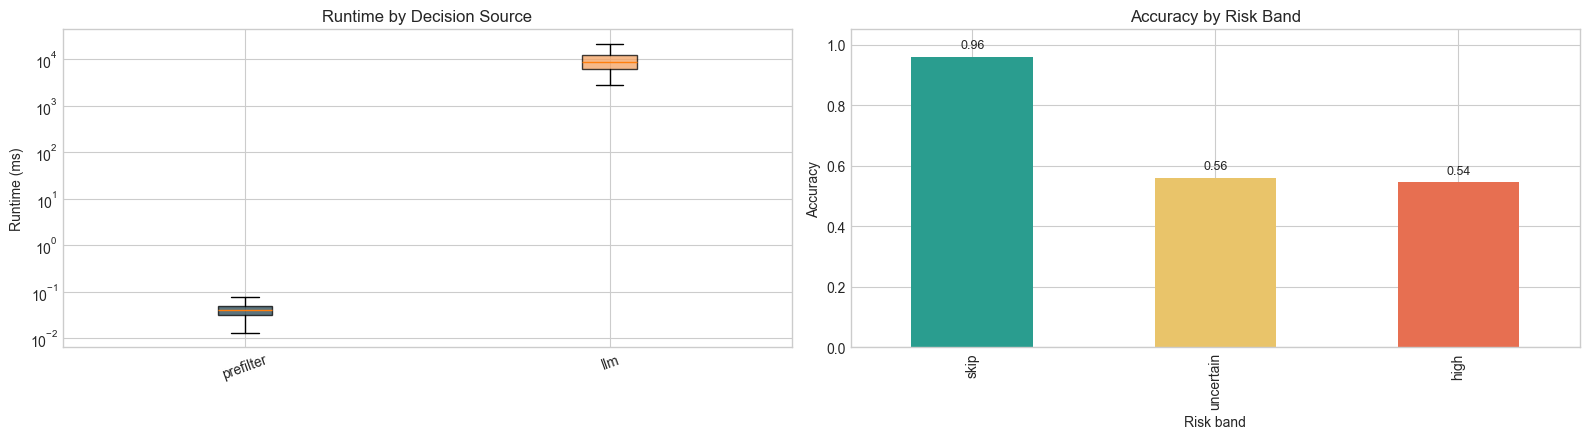

In [9]:
probability_bins = np.linspace(0, 1, 21)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for label_name in ['Non-vulnerable', 'Vulnerable']:
    subset = df[df['actual_label_name'] == label_name]
    axes[0, 0].hist(subset['calibrated_probability'].dropna(), bins=probability_bins, alpha=0.55, label=label_name, color=PALETTE[label_name])
axes[0, 0].set_title('Calibrated Probability by True Label')
axes[0, 0].set_xlabel('Calibrated probability')
axes[0, 0].set_ylabel('Samples')
axes[0, 0].legend()

for error_name in ERROR_ORDER:
    subset = df[df['error_type'] == error_name]
    if subset.empty:
        continue
    axes[0, 1].hist(subset['confidence_score'].dropna(), bins=probability_bins, alpha=0.5, label=error_name, color=PALETTE[error_name])
axes[0, 1].set_title('Confidence Score by Error Type')
axes[0, 1].set_xlabel('Confidence score')
axes[0, 1].set_ylabel('Samples')
axes[0, 1].legend()

draw_boxplot(axes[1, 0], [(band, df.loc[df['risk_band'] == band, 'record_runtime_ms']) for band in RISK_BAND_ORDER], 'Runtime by Risk Band', 'Runtime (ms)', log_scale=True)

for error_name in ERROR_ORDER:
    subset = df[df['error_type'] == error_name]
    if subset.empty:
        continue
    axes[1, 1].scatter(subset['confidence_score'], subset['record_runtime_ms'].clip(lower=1e-3), alpha=0.45, s=20, color=PALETTE[error_name], label=error_name)
axes[1, 1].set_title('Confidence vs Runtime')
axes[1, 1].set_xlabel('Confidence score')
axes[1, 1].set_ylabel('Runtime (ms)')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
draw_boxplot(axes[0], [(source, df.loc[df['decision_source'] == source, 'record_runtime_ms']) for source in DECISION_SOURCE_ORDER], 'Runtime by Decision Source', 'Runtime (ms)', log_scale=True)

risk_accuracy = df.groupby('risk_band')['is_correct'].mean().reindex(RISK_BAND_ORDER).fillna(0)
risk_accuracy.plot(kind='bar', ax=axes[1], color=pick_colors(risk_accuracy.index.tolist()))
axes[1].set_title('Accuracy by Risk Band')
axes[1].set_xlabel('Risk band')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
annotate_bars(axes[1], decimals=2)

plt.tight_layout()
plt.show()


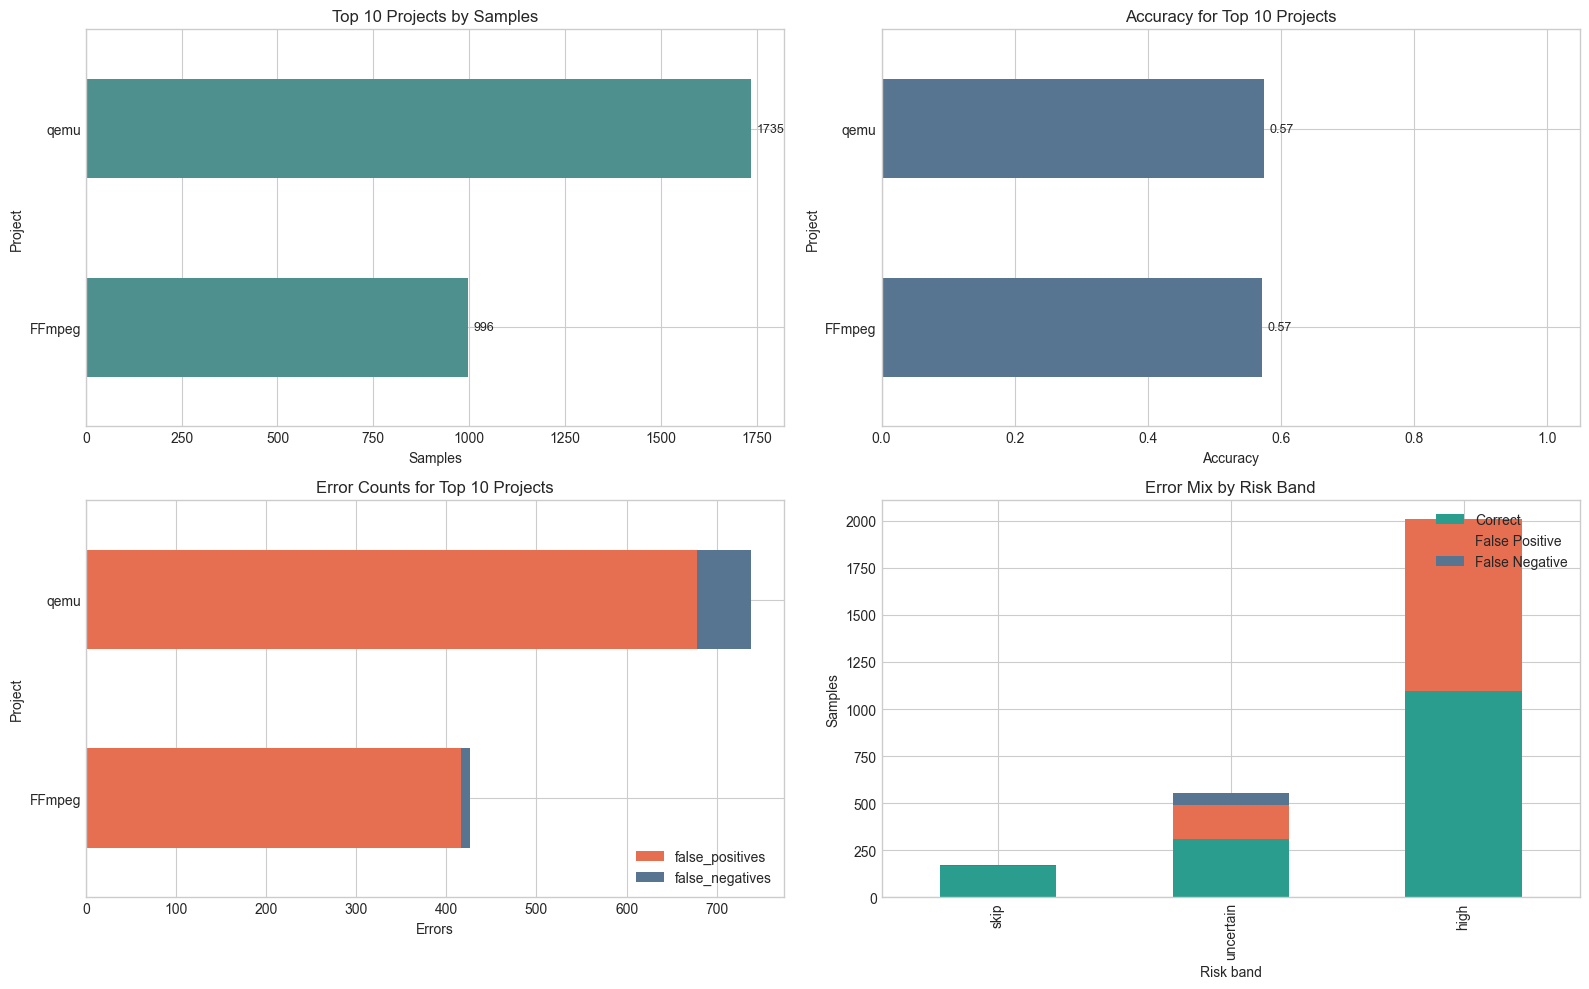

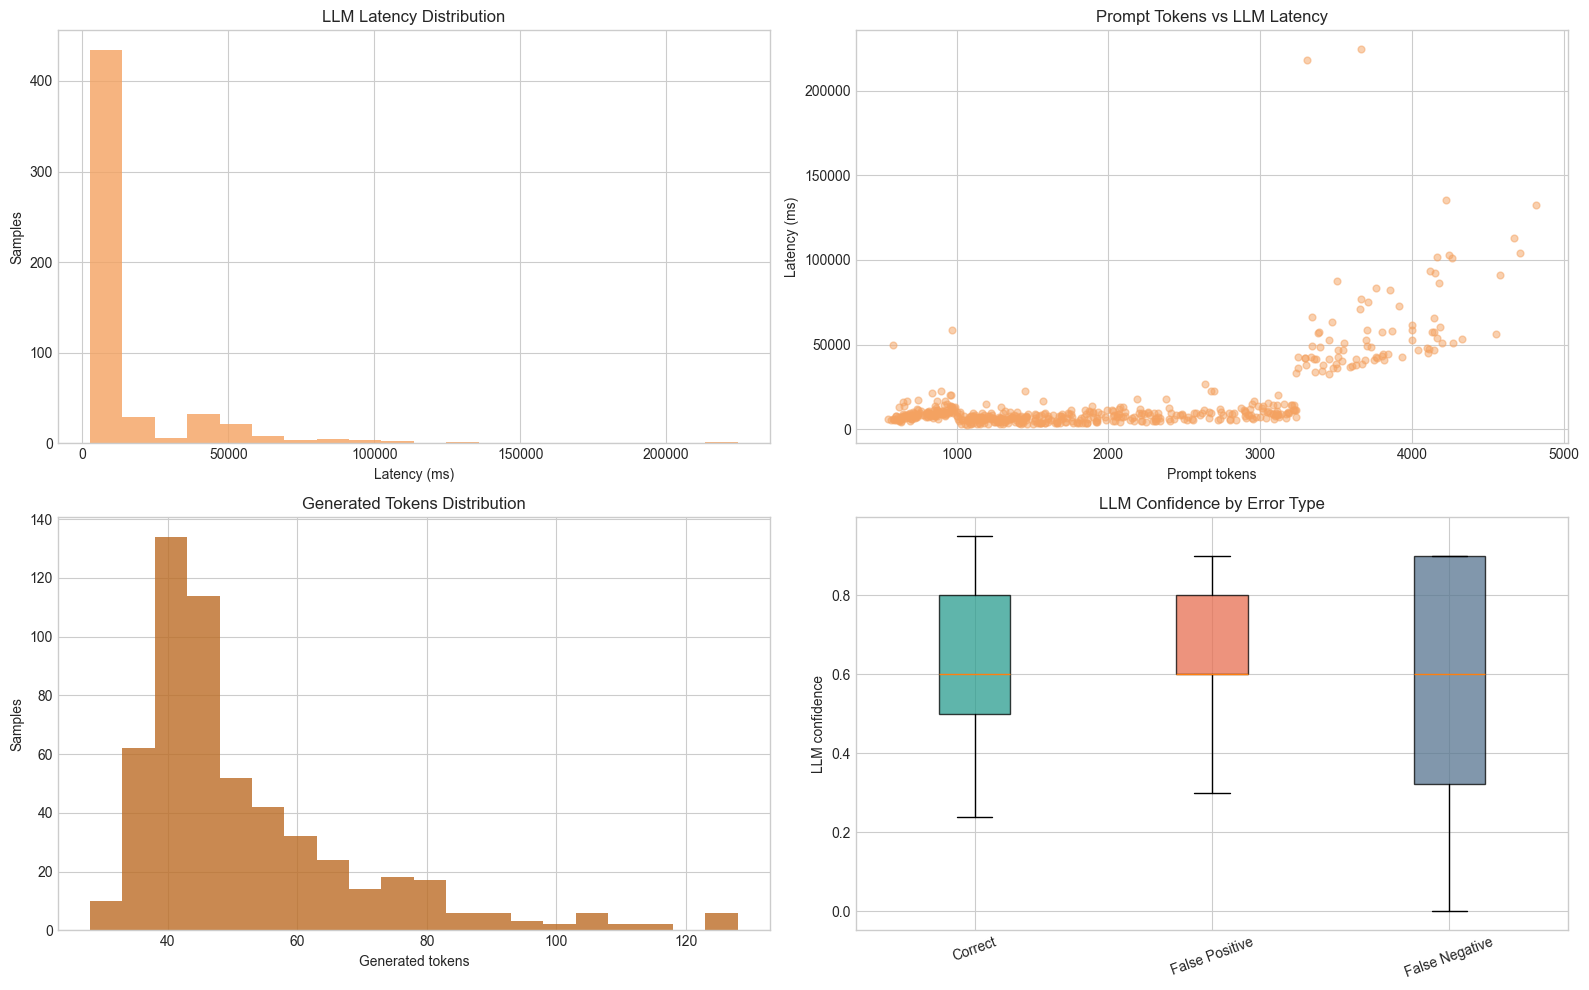

In [10]:
top_projects_by_samples = project_summary_df.head(TOP_K_PROJECTS).sort_values('samples')
top_projects_by_errors = project_summary_df.sort_values(['error_count', 'samples'], ascending=[False, False]).head(TOP_K_PROJECTS).sort_values('error_count')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
top_projects_by_samples['samples'].plot(kind='barh', ax=axes[0, 0], color='#4d908e')
axes[0, 0].set_title(f'Top {TOP_K_PROJECTS} Projects by Samples')
axes[0, 0].set_xlabel('Samples')
axes[0, 0].set_ylabel('Project')
annotate_bars(axes[0, 0], decimals=0)

top_projects_by_samples['accuracy'].plot(kind='barh', ax=axes[0, 1], color='#577590')
axes[0, 1].set_title(f'Accuracy for Top {TOP_K_PROJECTS} Projects')
axes[0, 1].set_xlabel('Accuracy')
axes[0, 1].set_ylabel('Project')
axes[0, 1].set_xlim(0, 1.05)
annotate_bars(axes[0, 1], decimals=2)

top_projects_by_errors[['false_positives', 'false_negatives']].plot(kind='barh', stacked=True, ax=axes[1, 0], color=[PALETTE['False Positive'], PALETTE['False Negative']])
axes[1, 0].set_title(f'Error Counts for Top {TOP_K_PROJECTS} Projects')
axes[1, 0].set_xlabel('Errors')
axes[1, 0].set_ylabel('Project')

error_mix_df = (
    df.groupby(['risk_band', 'error_type'])
    .size()
    .unstack(fill_value=0)
    .reindex(RISK_BAND_ORDER, fill_value=0)
    .reindex(columns=ERROR_ORDER, fill_value=0)
)
error_mix_df.plot(kind='bar', stacked=True, ax=axes[1, 1], color=[PALETTE[label] for label in ERROR_ORDER])
axes[1, 1].set_title('Error Mix by Risk Band')
axes[1, 1].set_xlabel('Risk band')
axes[1, 1].set_ylabel('Samples')
axes[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()

if not llm_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes[0, 0].hist(llm_df['llm_latency_ms'].dropna(), bins=20, color=PALETTE['llm'], alpha=0.8)
    axes[0, 0].set_title('LLM Latency Distribution')
    axes[0, 0].set_xlabel('Latency (ms)')
    axes[0, 0].set_ylabel('Samples')

    axes[0, 1].scatter(llm_df['llm_prompt_tokens'], llm_df['llm_latency_ms'], alpha=0.5, s=24, color=PALETTE['llm'])
    axes[0, 1].set_title('Prompt Tokens vs LLM Latency')
    axes[0, 1].set_xlabel('Prompt tokens')
    axes[0, 1].set_ylabel('Latency (ms)')

    axes[1, 0].hist(llm_df['llm_generated_tokens'].dropna(), bins=20, color='#bc6c25', alpha=0.8)
    axes[1, 0].set_title('Generated Tokens Distribution')
    axes[1, 0].set_xlabel('Generated tokens')
    axes[1, 0].set_ylabel('Samples')

    draw_boxplot(axes[1, 1], [(label, llm_df.loc[llm_df['error_type'] == label, 'llm_confidence']) for label in ERROR_ORDER], 'LLM Confidence by Error Type', 'LLM confidence', log_scale=False)
    plt.tight_layout()
    plt.show()
else:
    print('No LLM-routed samples in this run, so LLM-specific plots are skipped.')


In [11]:
routing_breakdown_df = (
    df.groupby(['risk_band', 'error_type'])
    .size()
    .unstack(fill_value=0)
    .reindex(RISK_BAND_ORDER, fill_value=0)
    .reindex(columns=ERROR_ORDER, fill_value=0)
)
routing_breakdown_df['samples'] = routing_breakdown_df.sum(axis=1)
routing_breakdown_df['accuracy'] = df.groupby('risk_band')['is_correct'].mean().reindex(routing_breakdown_df.index)
routing_display_df = routing_breakdown_df.reset_index().rename(columns={'risk_band': 'routing'})
routing_display_df['accuracy'] = routing_display_df['accuracy'].map(format_metric)

decision_breakdown_df = (
    df.groupby(['decision_source', 'error_type'])
    .size()
    .unstack(fill_value=0)
    .reindex(DECISION_SOURCE_ORDER, fill_value=0)
    .reindex(columns=ERROR_ORDER, fill_value=0)
)
decision_breakdown_df['samples'] = decision_breakdown_df.sum(axis=1)
decision_breakdown_df['accuracy'] = df.groupby('decision_source')['is_correct'].mean().reindex(decision_breakdown_df.index)
decision_display_df = decision_breakdown_df.reset_index().rename(columns={'decision_source': 'source'})
decision_display_df['accuracy'] = decision_display_df['accuracy'].map(format_metric)

project_display_df = project_summary_df.head(TOP_K_PROJECTS).reset_index().copy()
for column in ['accuracy', 'llm_call_ratio', 'avg_runtime_ms']:
    project_display_df[column] = project_display_df[column].map(format_metric)

show_section('Routing Breakdown')
display(routing_display_df)
show_section('Decision Source Breakdown')
display(decision_display_df)
show_section(f'Top {TOP_K_PROJECTS} Projects')
display(project_display_df)


## Routing Breakdown

error_type,routing,Correct,False Positive,False Negative,samples,accuracy
0,skip,164,0,7,171,0.9591
1,uncertain,309,180,63,552,0.5598
2,high,1094,914,0,2008,0.5448


## Decision Source Breakdown

error_type,source,Correct,False Positive,False Negative,samples,accuracy
0,prefilter,1258,914,7,2179,0.5773
1,llm,309,180,63,552,0.5598


## Top 10 Projects

,project,samples,accuracy,llm_call_ratio,avg_runtime_ms,false_positives,false_negatives,error_count
0,qemu,1735,0.5746,0.2484,3830.0570,678,60,738
1,FFmpeg,996,0.5723,0.1215,2604.3859,416,10,426


In [12]:
preview_columns = [
    'record_id',
    'project',
    'ground_truth',
    'prediction',
    'risk_band',
    'decision_source',
    'calibrated_probability',
    'llm_confidence',
    'record_runtime_ms',
    'reason',
]

false_positive_df = (
    df[df['error_type'] == 'False Positive']
    .sort_values(['confidence_score', 'record_runtime_ms'], ascending=[False, False])
    [preview_columns]
    .head(TOP_K_ERRORS)
    .copy()
)

false_negative_df = (
    df[df['error_type'] == 'False Negative']
    .sort_values(['confidence_score', 'record_runtime_ms'], ascending=[True, False])
    [preview_columns]
    .head(TOP_K_ERRORS)
    .copy()
)

for table in [false_positive_df, false_negative_df]:
    if not table.empty:
        table['calibrated_probability'] = table['calibrated_probability'].map(format_metric)
        table['llm_confidence'] = table['llm_confidence'].map(format_metric)
        table['record_runtime_ms'] = table['record_runtime_ms'].map(format_metric)
        table['reason'] = table['reason'].map(shorten_text)

show_section(f'False Positives (top {TOP_K_ERRORS})')
display(false_positive_df if not false_positive_df.empty else pd.DataFrame([{'note': 'No false positives.'}]))
show_section(f'False Negatives (top {TOP_K_ERRORS})')
display(false_negative_df if not false_negative_df.empty else pd.DataFrame([{'note': 'No false negatives.'}]))
show_section('Prediction Preview')
display(df[preview_columns].head(10))


## False Positives (top 20)

,record_id,project,ground_truth,prediction,risk_band,decision_source,calibrated_probability,llm_confidence,record_runtime_ms,reason
1692,devign-16894,qemu,0,1,high,prefilter,0.9020,0.9020,0.0390,prefilter_high_risk_accept
1846,devign-18324,FFmpeg,0,1,uncertain,llm,0.1810,0.9000,11756.4250,"The loop writing to out[i+32] exceeds the 91-element dimension when i reaches 58, causing an out-of-bounds write."
723,devign-7463,qemu,0,1,uncertain,llm,0.1526,0.9000,7621.4260,Returns pointer to array without bounds checking. Caller could pass invalid type leading to out-of-bounds access.
2093,devign-20778,FFmpeg,0,1,high,prefilter,0.8744,0.8744,0.0390,prefilter_high_risk_accept
920,devign-9479,FFmpeg,0,1,high,prefilter,0.8566,0.8566,0.0480,prefilter_high_risk_accept
144,devign-1442,FFmpeg,0,1,high,prefilter,0.8558,0.8558,0.0400,prefilter_high_risk_accept
222,devign-2284,qemu,0,1,high,prefilter,0.8512,0.8512,0.0320,prefilter_high_risk_accept
1079,devign-10892,qemu,0,1,uncertain,llm,0.3053,0.8500,16726.0980,"When error occurs, qapi_free_BlockInfoList(head) frees the list. If successful, the loop adds new nodes to head without freeing previous ones, causing leaks..."
2596,devign-25882,FFmpeg,0,1,uncertain,llm,0.1583,0.8500,14518.6090,The assembly code accesses memory using pointer arithmetic with line_size and h parameters without explicit bounds checks. If line_size is negative or h exc...
94,devign-995,FFmpeg,0,1,uncertain,llm,0.3171,0.8500,11425.4330,"The code calculates 'end' as s + src_size/2 without validating if src_size is positive. If src_size is negative, 'end' points before the buffer start. The l..."


## False Negatives (top 20)

,record_id,project,ground_truth,prediction,risk_band,decision_source,calibrated_probability,llm_confidence,record_runtime_ms,reason
1075,devign-10858,qemu,1,0,uncertain,llm,0.2407,0.0000,38066.0360,"No buffer overflows, out-of-bounds reads, or memory management issues detected. The code safely handles flag checks and prints data without unsafe operations."
1890,devign-18697,qemu,1,0,uncertain,llm,0.2864,0.0000,8208.5660,No memory operations or buffer accesses present. Only version/flags conversion via htonl.
1372,devign-13628,qemu,1,0,uncertain,llm,0.2276,0.0000,7405.9250,No direct memory operations or unsafe calls in the provided code.
321,devign-3394,qemu,1,0,uncertain,llm,0.1906,0.0000,7283.1730,Checks IQ_TAIL without buffer operations or pointer misuse. No memory safety issues detected.
2474,devign-24567,qemu,1,0,uncertain,llm,0.3085,0.0000,6257.6730,No memory operations or buffer accesses present. Only version/flags conversion via ntohl without array indexing or pointer arithmetic.
2403,devign-23845,qemu,1,0,uncertain,llm,0.2648,0.0000,5232.4200,No memory operations or buffer accesses present.
691,devign-7138,FFmpeg,1,0,uncertain,llm,0.2943,0.0000,4950.3340,No memory safety issues found. Protocols are properly freed in error paths without double-free. No use-after-free or buffer overflows detected.
1865,devign-18469,qemu,1,0,uncertain,llm,0.3002,0.3000,9222.1940,Checks ri->crm >8 prevent out-of-bounds access. c6_region array size likely accommodates crm values 0-8. No integer overflow or unsafe API usage detected.
2000,devign-19773,FFmpeg,1,0,uncertain,llm,0.3068,0.3000,6148.3390,"Checks buffer size implicitly via AV_RL32, which requires at least 4 bytes. No explicit check, but function likely expects valid input."
1805,devign-17864,qemu,1,0,uncertain,llm,0.3055,0.3055,10341.3030,No memory operations or buffer accesses here. Checks focus on control flow without unsafe interactions.


## Prediction Preview

,record_id,project,ground_truth,prediction,risk_band,decision_source,calibrated_probability,llm_confidence,record_runtime_ms,reason
0,devign-7,FFmpeg,1,1,uncertain,llm,0.278909,0.800000,14979.728,Potential out-of-bounds read in memcmp due to unvalidated buffer size when depth_byte causes (WIDTH - i) to exceed buffer allocation.
1,devign-9,qemu,1,1,high,prefilter,0.677568,0.677568,0.118,prefilter_high_risk_accept
2,devign-53,qemu,0,1,high,prefilter,0.361643,0.361643,0.028,prefilter_high_risk_accept
3,devign-73,qemu,0,1,uncertain,llm,0.289519,0.600000,4402.897,"No bounds checks on s->pwl.base before passing to cpu_register_physical_memory, risking out-of-bounds access."
4,devign-74,qemu,0,0,skip,prefilter,0.143557,0.856443,0.130,prefilter_skip
5,devign-77,qemu,1,1,high,prefilter,0.536414,0.536414,0.041,prefilter_high_risk_accept
6,devign-78,FFmpeg,1,1,high,prefilter,0.409171,0.409171,0.026,prefilter_high_risk_accept
7,devign-86,qemu,1,1,high,prefilter,0.427450,0.427450,0.042,prefilter_high_risk_accept
8,devign-125,FFmpeg,1,1,high,prefilter,0.765377,0.765377,0.028,prefilter_high_risk_accept
9,devign-132,qemu,1,1,high,prefilter,0.365934,0.365934,0.032,prefilter_high_risk_accept


In [13]:
comparison = metrics.get('comparison')
if comparison:
    comparison_df = pd.DataFrame([
        {'metric': 'Aligned samples', 'value': comparison.get('aligned_samples')},
        {'metric': 'Baseline F1', 'value': format_metric(comparison.get('baseline_f1'))},
        {'metric': 'Current F1', 'value': format_metric(comparison.get('current_f1'))},
        {'metric': 'McNemar n01', 'value': comparison.get('mcnemar', {}).get('n01')},
        {'metric': 'McNemar n10', 'value': comparison.get('mcnemar', {}).get('n10')},
        {'metric': 'McNemar p-value', 'value': format_metric(comparison.get('mcnemar', {}).get('p_value'))},
        {'metric': 'Baseline file', 'value': comparison.get('baseline_compare_path')},
    ])
    show_section('Baseline Comparison')
    display(comparison_df)
else:
    print('No baseline comparison. Set BASELINE_COMPARE_PATH to another predictions jsonl to enable McNemar/F1 comparison.')


No baseline comparison. Set BASELINE_COMPARE_PATH to another predictions jsonl to enable McNemar/F1 comparison.
